# Table of Contents

1. [Introduction](#1.-Introduction)

2. [Importing Libraries And Loading Model Dataset](#2.-Importing-Libraries-And-Loading-Model-Dataset)

3. [ETS (A, Ad, N) Concept Introduction](#3.-ETS-Concept-Introduction)

4. [Model Fitting](#4.-Model-Fitting)

5. [Forecasting CO₂ Emissions to 2043](#5.-Forecasting-CO2-Emissions-to-2043)

6. [ETS Forecast Trend Interpretation](#6.-ETS-Forecast-Trend-Interpretation)

7. [Forecast Summary Table](#7.-Forecast-Summary-Table)

8. [Model Validation](#8.-Model-Validation)

9. [Final Model Comparison](#9.-Final-Model-Comparison)

10. [Week 4 Conclusion](#10.-Week-4-Conclusion)


# 1. Introduction

Time-series forecasting focuses on predicting future values by analyzing patterns in historical data.

In this stage, the ETS(A,Ad,N) model is applied to country-wise CO₂ emission data to forecast future emission trends.

Unlike machine learning regression models that depend on engineered input features, ETS directly models the historical time-series behavior using level and trend components.

# 2. Importing Libraries And Loading Model Dataset

In [2]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# 3. ETS Concept Introduction

ETS (Error, Trend, Seasonality) is a time-series forecasting method that models data using three components: error, trend, and seasonality.

In this project, ETS(A,Ad,N) is used:

- Error (A): Additive error assumes prediction errors are added to the model state.
- Trend (Ad): Additive damped trend allows emissions to continue increasing or decreasing while gradually slowing the trend over long forecasting horizons.
- Seasonality (N): No seasonal component is included because annual CO₂ emission data does not contain repeating within-year cycles.

ETS(A,Ad,N) is suitable for annual emissions forecasting because it can capture long-term trends while avoiding unrealistic unlimited growth through the damping parameter.

Explain why ETS(A,Ad,N) is appropriate for annual emissions data:
-No within-year seasonality to model
-	Damped trend prevents unbounded long-range projections (unlike a unit-root ARIMA)
-	Works reliably with approximately 30 data points — fewer free parameters than many alternatives
-	Physically sensible: emissions trajectories in real economies tend to slow, plateau, or gradually reverse — not grow at a constant rate indefinitely

# 4. Model Fitting

In [3]:
model_data = pd.read_csv(
    "data/model_data.csv"
)

ets_data = model_data[
    [
        "country",
        "year",
        "co2"
    ]
].copy()

ets_data.head()

,country,year,co2
0,Australia,1994,293.613
1,Australia,1995,304.962
2,Australia,1996,311.851
3,Australia,1997,320.243
4,Australia,1998,334.038


In [4]:
ets_models = {}
ets_parameters = []

In [5]:
ets_models = {}

ets_parameters = []


for country in ets_data["country"].unique():

    country_data = (
        ets_data[
            ets_data["country"] == country
        ]
        .sort_values("year")
    )


    train_co2 = (
        country_data[
            country_data["year"] <= 2018
        ]
        .set_index("year")["co2"]
    )


    model = ExponentialSmoothing(
        train_co2,
        trend="add",
        damped_trend=True,
        seasonal=None
    )


    fit = model.fit(
        optimized=True
    )


    ets_models[country] = fit


    ets_parameters.append({

        "Country": country,

        "Alpha": fit.params["smoothing_level"],

        "Beta": fit.params["smoothing_trend"],

        "Phi": fit.params["damping_trend"]

    })

In [6]:
ets_parameters = pd.DataFrame(
    ets_parameters
)

ets_parameters

,Country,Alpha,Beta,Phi
0,Australia,1.000000e+00,0.000000e+00,0.915932
1,Brazil,1.000000e+00,0.000000e+00,0.949855
2,China,1.000000e+00,8.886142e-01,0.857210
3,Germany,1.490116e-08,1.298034e-08,0.995000
4,India,6.423798e-01,6.423798e-01,0.995000
5,Japan,1.000000e+00,0.000000e+00,0.995000
6,Russia,9.699278e-01,0.000000e+00,0.995000
7,South Africa,7.079955e-01,0.000000e+00,0.919128
8,United Kingdom,5.295254e-01,3.493202e-01,0.995000
9,United States,6.707934e-01,1.990756e-01,0.800000


##### ETS Parameter Interpretation

The fitted ETS(A,Ad,N) models produced smoothing parameters α, β*, and φ for each country.

The alpha parameter controls how strongly the model responds to recent emission levels. Countries with higher alpha values give more importance to recent observations, while lower values produce smoother estimates.

The beta parameter controls how quickly the estimated trend changes over time. Lower beta values indicate a more stable long-term trend.

The damping parameter φ controls future trend extrapolation. Values close to 1 allow the trend to continue for longer, while lower values gradually reduce the trend strength. This prevents unrealistic long-term emission forecasts by slowing growth or decline over the forecast horizon.

# 5. Forecasting CO2 Emissions to 2043

The fitted ETS(A,Ad,N) models are used to generate long-term forecasts from 2024 to 2043 for each of the 10 countries.

The models use historical emission patterns learned from the training period to estimate future trajectories. The damped trend component prevents unrealistic unlimited growth by gradually reducing the strength of the projected trend over time.

In [7]:
ets_forecasts = []


for country, fit in ets_models.items():

    forecast = fit.forecast(
        steps=20
    )


    years = range(
        2024,
        2044
    )


    for year, value in zip(years, forecast):

        ets_forecasts.append({

            "Country": country,

            "Year": year,

            "Forecast_CO2": value

        })

In [8]:
ets_forecasts = pd.DataFrame(
    ets_forecasts
)

ets_forecasts.head()

,Country,Year,Forecast_CO2
0,Australia,2024,416.208193
1,Australia,2025,417.515405
2,Australia,2026,418.712722
3,Australia,2027,419.809384
4,Australia,2028,420.813852


In [9]:
ets_forecasts[
    ets_forecasts["Country"]=="India"
]

,Country,Year,Forecast_CO2
80,India,2024,2693.232828
81,India,2025,2812.440965
82,India,2026,2931.053062
83,India,2027,3049.072098
84,India,2028,3166.501039
85,India,2029,3283.342835
86,India,2030,3399.600422
87,India,2031,3515.276721
88,India,2032,3630.374639
89,India,2033,3744.897067


In [10]:
ets_forecasts.to_csv(
    "data/ets_forecasts.csv",
    index=False
)

In [11]:
ets_forecasts.head()

,Country,Year,Forecast_CO2
0,Australia,2024,416.208193
1,Australia,2025,417.515405
2,Australia,2026,418.712722
3,Australia,2027,419.809384
4,Australia,2028,420.813852


In [12]:
def plot_ets_forecast(country):

    country_data = (
        ets_data[
            ets_data["country"] == country
        ]
        .sort_values("year")
    )


    train = country_data[
        country_data["year"] <= 2018
    ]

    fitted = ets_models[country].fittedvalues


    test = country_data[
        country_data["year"] >= 2019
    ]


    forecast = ets_forecasts[
        ets_forecasts["Country"] == country
    ]


    plt.figure(figsize=(10,5))





    plt.plot(
        train["year"],
        train["co2"],
        label="Training Actual (1990-2018)"
    )

    plt.plot(
    fitted.index,
    fitted.values,
    label="ETS Fitted Values"
            
     )


    plt.plot(
        test["year"],
        test["co2"],
        label="Holdout Actual (2019-2023)"
    )


    plt.plot(
        forecast["Year"],
        forecast["Forecast_CO2"],
        label="ETS Forecast (2024-2043)"
    )


    plt.title(
        f"ETS CO₂ Forecast: {country}"
    )

    plt.xlabel("Year")

    plt.ylabel("CO₂ Emissions")

    plt.legend()

    plt.grid()

    plt.show()

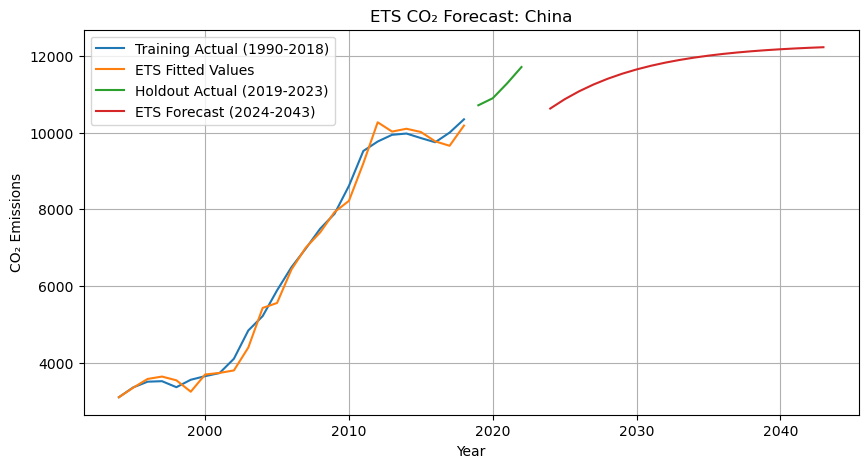

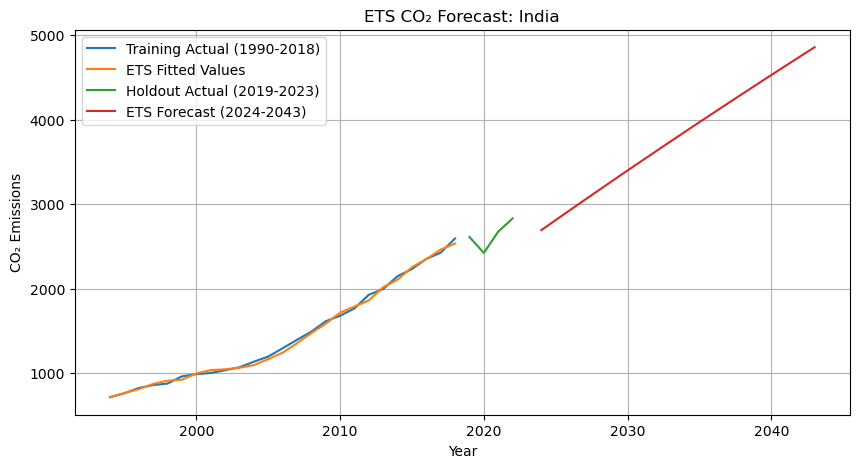

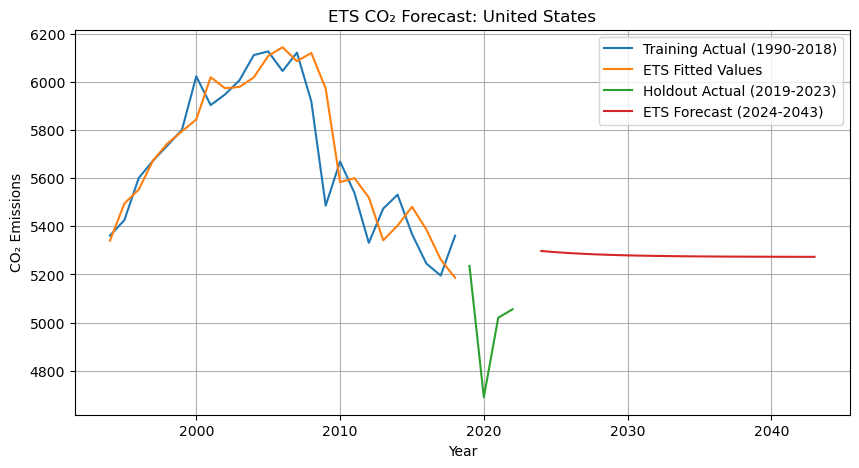

In [13]:
plot_ets_forecast(
    "China"
)

plot_ets_forecast(
    "India"
)

plot_ets_forecast(
    "United States"
)

# 6. ETS Forecast Trend Interpretation



The ETS(A,Ad,N) model forecasts future CO₂ emissions by extending historical trends while using a damping parameter to prevent unrealistic long-term growth or decline.

##### China

China's historical CO₂ emissions show rapid growth, especially after the early 2000s. The ETS forecast projects that emissions will continue increasing but the rate of growth gradually slows over the forecast period.

The damped trend behaviour is realistic because the model does not assume that China's previous rapid growth will continue indefinitely. The lower damping parameter reduces the trend strength over time, causing emissions to approach a more stable trajectory.

##### India

India's emissions show a consistent upward trend throughout the historical data. The ETS forecast continues this increasing trajectory, suggesting continued emissions growth in future years.

The damping effect is weaker because India's historical trend has remained relatively consistent. The forecast reflects continued growth while still applying trend damping to avoid unlimited extrapolation.

##### United States

United States emissions increased until the early 2000s before entering a declining trend. The ETS forecast projects a more stable future pathway instead of continuing a sharp decrease indefinitely.

The damped trend component reduces the strength of the downward trend over time. This produces a more realistic long-term forecast where emissions gradually stabilize.

##### Confidence Interval Interpretation

Forecast uncertainty increases as the prediction horizon becomes longer. Therefore, confidence intervals generally become wider for later years such as 2040-2043 compared with short-term forecasts.

A wider interval indicates that long-term emission predictions contain greater uncertainty because future economic, technological, and policy changes cannot be perfectly captured from historical data alone.

# 7. Forecast Summary Table

In [14]:
forecast_summary = (
    ets_forecasts[
        ets_forecasts["Year"].isin(
            [2030, 2035, 2040]
        )
    ]
)

forecast_summary.head()

,Country,Year,Forecast_CO2
6,Australia,2030,422.576556
11,Australia,2035,425.839173
16,Australia,2040,427.942383
26,Brazil,2030,504.877472
31,Brazil,2035,519.671783


In [15]:
forecast_summary = forecast_summary.pivot(
    index="Country",
    columns="Year",
    values="Forecast_CO2"
)

forecast_summary.head()

Year,2030,2035,2040
Country,,,
Australia,422.576556,425.839173,427.942383
Brazil,504.877472,519.671783,531.110632
China,11648.320184,12008.640092,12175.412688
Germany,722.028205,687.737631,654.295792
India,3399.600422,3972.226950,4530.680258


In [16]:
forecast_summary.columns = [
    "2030 Forecast",
    "2035 Forecast",
    "2040 Forecast"
]

forecast_summary = forecast_summary.reset_index()

forecast_summary

,Country,2030 Forecast,2035 Forecast,2040 Forecast
0,Australia,422.576556,425.839173,427.942383
1,Brazil,504.877472,519.671783,531.110632
2,China,11648.320184,12008.640092,12175.412688
3,Germany,722.028205,687.737631,654.295792
4,India,3399.600422,3972.226950,4530.680258
5,Japan,1117.815005,1103.443459,1089.427627
6,Russia,1722.449664,1732.136140,1741.582864
7,South Africa,460.156704,463.633361,465.913926
8,United Kingdom,262.231337,184.482744,108.658526
9,United States,5279.347736,5275.010656,5273.589481


In [17]:
actual_2020 = (
    ets_data[
        ets_data["year"] == 2020
    ]
    [
        [
            "country",
            "co2"
        ]
    ]
)

actual_2020.head()

,country,co2
26,Australia,398.547
55,Brazil,447.999
84,China,10896.521
113,Germany,647.177
142,India,2422.732


In [18]:
actual_2020 = actual_2020.rename(
    columns={
        "country":"Country",
        "co2":"2020 Actual"
    }
)

In [19]:
forecast_summary = forecast_summary.merge(
    actual_2020,
    on="Country"
)

forecast_summary

,Country,2030 Forecast,2035 Forecast,2040 Forecast,2020 Actual
0,Australia,422.576556,425.839173,427.942383,398.547
1,Brazil,504.877472,519.671783,531.110632,447.999
2,China,11648.320184,12008.640092,12175.412688,10896.521
3,Germany,722.028205,687.737631,654.295792,647.177
4,India,3399.600422,3972.226950,4530.680258,2422.732
5,Japan,1117.815005,1103.443459,1089.427627,1037.285
6,Russia,1722.449664,1732.136140,1741.582864,1631.902
7,South Africa,460.156704,463.633361,465.913926,435.298
8,United Kingdom,262.231337,184.482744,108.658526,326.263
9,United States,5279.347736,5275.010656,5273.589481,4689.954


In [20]:
forecast_summary[
    "% Change 2020-2040"
] = (
    (
        forecast_summary["2040 Forecast"]
        -
        forecast_summary["2020 Actual"]
    )
    /
    forecast_summary["2020 Actual"]
) * 100


forecast_summary

,Country,2030 Forecast,2035 Forecast,2040 Forecast,2020 Actual,% Change 2020-2040
0,Australia,422.576556,425.839173,427.942383,398.547,7.375638
1,Brazil,504.877472,519.671783,531.110632,447.999,18.551745
2,China,11648.320184,12008.640092,12175.412688,10896.521,11.736697
3,Germany,722.028205,687.737631,654.295792,647.177,1.099976
4,India,3399.600422,3972.226950,4530.680258,2422.732,87.007075
5,Japan,1117.815005,1103.443459,1089.427627,1037.285,5.026837
6,Russia,1722.449664,1732.136140,1741.582864,1631.902,6.721045
7,South Africa,460.156704,463.633361,465.913926,435.298,7.033326
8,United Kingdom,262.231337,184.482744,108.658526,326.263,-66.696032
9,United States,5279.347736,5275.010656,5273.589481,4689.954,12.444375


##### Forecast Summary Interpretation

The ETS forecast summary shows different future emission trajectories among countries.

India shows the highest projected growth, with emissions increasing significantly by 2040 due to its strong historical upward trend.

China's emissions are forecasted to continue increasing but at a slower rate because the damped trend limits long-term growth.

The United Kingdom shows a projected decrease in emissions, reflecting its historical downward trend.

Overall, the damped ETS model produces realistic long-term forecasts by allowing trends to continue while reducing the possibility of unlimited growth or decline.

# 8. Model Validation

In [21]:
ets_results = []


for country, fit in ets_models.items():


    country_data = (
        ets_data[
            ets_data["country"] == country
        ]
        .sort_values("year")
    )


    test_actual = (
        country_data[
            country_data["year"] >= 2019
        ]["co2"]
    )


    ets_prediction = fit.forecast(
        steps=len(test_actual)
    )


    mae = mean_absolute_error(
        test_actual,
        ets_prediction
    )


    rmse = root_mean_squared_error(
        test_actual,
        ets_prediction
    )


    ets_results.append({

        "Country": country,

        "ETS MAE": mae,

        "ETS RMSE": rmse

    })

In [22]:
ets_results = pd.DataFrame(
    ets_results
)


ets_results

,Country,ETS MAE,ETS RMSE
0,Australia,21.555926,25.262027
1,Brazil,15.708092,20.512474
2,China,194.262699,255.194051
3,Germany,78.238684,80.701426
4,India,236.245488,260.417841
5,Japan,74.196564,78.502475
6,Russia,41.929035,49.550924
7,South Africa,20.472163,21.014300
8,United Kingdom,10.028868,11.878864
9,United States,290.712742,350.717122


In [23]:
comparison_table = pd.read_csv(
    "data/comparison_table.csv"
)

comparison_table.head()

,Country,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF MAE,RF RMSE,Best Model
0,Australia,6.7002,8.887581,27.036408,27.928804,11.112230,12.892983,Baseline
1,Brazil,19.7412,26.352645,27.945234,32.116456,20.381490,22.915405,Baseline
2,China,315.1044,344.121882,131.063361,137.381203,1061.647585,1163.738791,Linear Regression
3,Germany,39.5944,46.431112,39.309512,43.093958,81.481080,86.868123,Linear Regression
4,India,191.8378,197.188147,177.975527,199.494428,115.726503,146.684899,Random Forest


In [24]:
final_comparison = comparison_table.merge(
    ets_results,
    on="Country"
)

final_comparison = final_comparison[
    [
        "Country",
        
        "Baseline MAE",
        "LR MAE",
        "RF MAE",
        "ETS MAE",
        
        "Baseline RMSE",
        "LR RMSE",
        "RF RMSE",
        "ETS RMSE",
        
        "Best Model"
    ]
]

final_comparison



,Country,Baseline MAE,LR MAE,RF MAE,ETS MAE,Baseline RMSE,LR RMSE,RF RMSE,ETS RMSE,Best Model
0,Australia,6.7002,27.036408,11.112230,21.555926,8.887581,27.928804,12.892983,25.262027,Baseline
1,Brazil,19.7412,27.945234,20.381490,15.708092,26.352645,32.116456,22.915405,20.512474,Baseline
2,China,315.1044,131.063361,1061.647585,194.262699,344.121882,137.381203,1163.738791,255.194051,Linear Regression
3,Germany,39.5944,39.309512,81.481080,78.238684,46.431112,43.093958,86.868123,80.701426,Linear Regression
4,India,191.8378,177.975527,115.726503,236.245488,197.188147,199.494428,146.684899,260.417841,Random Forest
5,Japan,36.5260,35.154724,91.559447,74.196564,39.830915,38.106028,94.326490,78.502475,Linear Regression
6,Russia,44.2358,56.857143,33.610298,41.929035,50.307134,64.873197,36.662727,49.550924,Random Forest
7,South Africa,12.2652,14.687995,15.531923,20.472163,17.077892,15.992982,18.536612,21.014300,Baseline
8,United Kingdom,18.8426,19.990089,48.447217,10.028868,23.468566,25.233003,48.807921,11.878864,Baseline
9,United States,212.5380,293.630418,347.458805,290.712742,292.332458,374.592585,371.901873,350.717122,Baseline


In [25]:
final_comparison["Best Model"] = (
    final_comparison[
        [
            "Baseline MAE",
            "LR MAE",
            "RF MAE",
            "ETS MAE"
        ]
    ]
    .idxmin(axis=1)
)

In [26]:
final_comparison["Best Model"] = (
    final_comparison["Best Model"]
    .replace({

        "Baseline MAE": "Naive Baseline",

        "LR MAE": "Linear Regression",

        "RF MAE": "Random Forest",

        "ETS MAE": "ETS(A,Ad,N)"

    })
)




final_comparison

final_comparison.to_csv(
    "data/final_comparison.csv",
    index=False
)



# 9. Final Model Comparison



Four forecasting approaches were compared: Naive Baseline, Linear Regression, Random Forest, and ETS(A,Ad,N).

The results show that model performance varies between countries because each country follows a different emissions pattern.

Machine learning models perform well when engineered historical features capture emission behavior, while ETS performs well for countries with clear time-dependent trends.

The comparison demonstrates that more complex models are not always superior, and model selection should be based on validation performance rather than algorithm complexity.

# 10. Week 4 Conclusion

In this notebook, ETS(A,Ad,N) time-series forecasting was successfully implemented to predict future CO₂ emissions.

The damped trend component allowed long-term forecasting while preventing unrealistic continuous growth or decline.

Forecasts were generated up to 2043 and analyzed using visualizations and summary tables.

Finally, ETS performance was compared with machine learning approaches, showing that different forecasting techniques perform better depending on each country's emission behavior.

This completes the end-to-end workflow from data exploration and feature engineering to machine learning and time-series forecasting.